# Fashion-MNIST — `xp` MLP

MNIST 와 같은 28×28 grayscale 이지만 **시각적으로 더 비슷한 클래스** (셔츠/풀오버/코트, 운동화/샌들/앵클부츠) 라 MLP 의 천장이 낮다.

- 입력 shape 은 MNIST 와 동일 → `xp_mnist.ipynb` 의 모델/학습 루프 그대로 재사용
- 데이터셋 이름만 `Fashion-MNIST` 로 바꿈
- 같은 모델로 MNIST 97%+, Fashion-MNIST 88%+ 가 한계 — 더 짜내려면 CNN 필요
- NumPy / MLX 두 백엔드 동시 학습 후 결과 비교

In [1]:
import time
from abc import ABC, abstractmethod
from collections.abc import Iterator

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import fetch_openml
from tqdm.notebook import tqdm

import axon
from axon import DType, xp
from axon.backend import Array, BackendName

## Optimizer

In [2]:
class Optimizer(ABC):
  def __init__(self, *, lr: float = 0.01):
    self._lr = lr

  @property
  def lr(self) -> float:
    return self._lr

  @lr.setter
  def lr(self, value: float):
    assert value > 0, "lr은 0보다 커야 합니다."
    self._lr = value

  @abstractmethod
  def step(self, X: Array, dX: Array): ...


class SGD(Optimizer):
  def step(self, X: Array, dX: Array):
    X -= dX * self.lr


class Adam(Optimizer):
  def __init__(self, *, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    super().__init__(lr=lr)
    self.beta1 = beta1
    self.beta2 = beta2
    self.eps = eps
    self.t = 0
    self.m: dict[int, Array] = {}
    self.v: dict[int, Array] = {}

  def step(self, X: Array, dX: Array):
    param_id = id(X)
    if param_id not in self.m:
      self.m[param_id] = xp.zeros_like(X)
      self.v[param_id] = xp.zeros_like(X)

    self.t += 1
    self.m[param_id] = self.beta1 * self.m[param_id] + (1 - self.beta1) * dX
    self.v[param_id] = self.beta2 * self.v[param_id] + (1 - self.beta2) * dX**2

    m_hat = self.m[param_id] / (1 - self.beta1**self.t)
    v_hat = self.v[param_id] / (1 - self.beta2**self.t)

    X -= self.lr * m_hat / (xp.sqrt(v_hat) + self.eps)

## Module / Layer

In [3]:
class Module(ABC):
  @abstractmethod
  def forward(self, X: Array) -> Array: ...

  @abstractmethod
  def backward(self, delta: Array) -> Array: ...

  @abstractmethod
  def optimize(self, optimizer: Optimizer): ...

  @abstractmethod
  def format(self, indent: int = 0) -> str: ...

  def __str__(self):
    return self.format()

  def __repr__(self):
    return self.format()


class Linear(Module):
  W: Array[DType.FLOAT32]
  b: Array[DType.FLOAT32]
  dW: Array[DType.FLOAT32] | None
  db: Array[DType.FLOAT32] | None

  def __init__(self, in_features: int, out_features: int):
    self.in_features = in_features
    self.out_features = out_features
    self._cache_X: Array | None = None
    self.W = xp.random.normal((out_features, in_features), std=0.05, dtype=DType.FLOAT32)
    self.b = xp.zeros((out_features,), dtype=DType.FLOAT32)
    self.dW = None
    self.db = None

  def forward(self, X: Array) -> Array:
    self._cache_X = X
    return X @ xp.transpose(self.W) + self.b

  def backward(self, delta: Array) -> Array:
    X = self._cache_X
    assert X is not None, "forward 이전에 backward 호출 불가."
    self.db = xp.sum(delta, axis=0)
    self.dW = xp.transpose(delta) @ X
    return delta @ self.W

  def optimize(self, optimizer: Optimizer):
    assert self.dW is not None and self.db is not None
    optimizer.step(self.W, self.dW)
    optimizer.step(self.b, self.db)

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}Linear(in={self.in_features}, out={self.out_features})"


class ReLU(Module):
  def __init__(self):
    self._cache_X: Array | None = None

  def forward(self, X: Array) -> Array:
    self._cache_X = X
    return xp.maximum(xp.zeros_like(X), X)

  def backward(self, delta: Array) -> Array:
    X = self._cache_X
    assert X is not None
    return delta * (X > 0)

  def optimize(self, optimizer: Optimizer):
    pass

  def format(self, indent: int = 0) -> str:
    return f"{'  ' * indent}ReLU()"


class Sequential(Module):
  def __init__(self, modules: list[Module]):
    assert len(modules) > 0
    self.modules = modules

  def forward(self, X: Array) -> Array:
    x = X
    for module in self.modules:
      x = module.forward(x)
    return x

  def backward(self, delta: Array) -> Array:
    dX = delta
    for module in reversed(self.modules):
      dX = module.backward(dX)
    return dX

  def optimize(self, optimizer: Optimizer):
    for module in self.modules:
      module.optimize(optimizer)

  def format(self, indent: int = 0) -> str:
    indent_str = "  " * indent
    lines = [f"{indent_str}Sequential("]
    for module in self.modules:
      lines.append(f"{module.format(indent + 1)},")
    lines.append(f"{indent_str})")
    return "\n".join(lines)

## Loss

In [4]:
class Loss(ABC):
  @abstractmethod
  def forward(self, Y: Array, T: Array) -> Array: ...

  @abstractmethod
  def backward(self) -> Array: ...


class CrossEntropyLoss(Loss):
  def __init__(self):
    self._cache_probs: Array | None = None
    self._cache_T: Array | None = None
    self._cache_N: int | None = None

  def forward(self, Y: Array, T: Array) -> Array:
    """반환은 0-d Array (Python float 아님 — on-device 누적용)."""
    N = Y.shape[0]
    max_by_row = xp.max(Y, axis=1, keepdims=True)
    shifted = Y - max_by_row
    exp_shifted = xp.exp(shifted)
    sum_by_row = xp.sum(exp_shifted, axis=1, keepdims=True)
    probs = exp_shifted / sum_by_row

    n = xp.arange(N, dtype=DType.INT32)
    log_probs = xp.log(probs[n, T] + 1e-9)

    self._cache_probs = probs
    self._cache_T = T
    self._cache_N = N

    return -xp.mean(log_probs)

  def backward(self) -> Array:
    probs = self._cache_probs
    T = self._cache_T
    N = self._cache_N
    assert probs is not None and T is not None and N is not None

    dY = xp.array(probs)
    n = xp.arange(N, dtype=DType.INT32)
    dY[n, T] -= 1.0
    dY /= N
    return dY


## Fashion-MNIST 로드

OpenML 에서 `Fashion-MNIST` (대소문자 구분). 28×28 grayscale, 10 클래스, train 60k / test 10k 로 MNIST 와 동일 shape.

In [5]:
FASHION_CLASSES = [
  "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False, parser="liac-arff")
X_all = fashion.data.astype(np.float32) / 255.0
T_all = fashion.target.astype(np.int32)

X_train_np, X_test_np = X_all[:60000], X_all[60000:]
T_train_np, T_test_np = T_all[:60000], T_all[60000:]

print("train:", X_train_np.shape, "test:", X_test_np.shape)
print("classes:", FASHION_CLASSES)

train: (60000, 784) test: (10000, 784)
classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


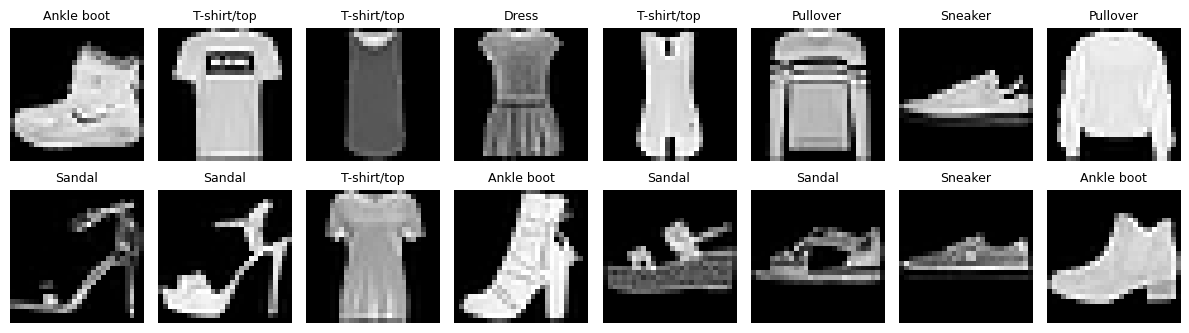

In [6]:
# 샘플 이미지 살짝 보기
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i, ax in enumerate(axes.flat):
  ax.imshow(X_train_np[i].reshape(28, 28), cmap="gray")
  ax.set_title(FASHION_CLASSES[T_train_np[i]], fontsize=9)
  ax.axis("off")
plt.tight_layout()
plt.show()

## 학습 루프

In [7]:
def iterate_minibatches(
  X_np: np.ndarray, T_np: np.ndarray, batch_size: int, *, shuffle: bool = False
) -> Iterator[tuple[Array, Array]]:
  N = X_np.shape[0]
  indices = np.random.permutation(N) if shuffle else np.arange(N)
  for start in range(0, N, batch_size):
    batch_idx = indices[start : start + batch_size]
    yield xp.from_numpy(X_np[batch_idx]), xp.from_numpy(T_np[batch_idx])


def run_epoch(
  module: Module,
  loss_fn: Loss,
  X_np: np.ndarray,
  T_np: np.ndarray,
  *,
  batch_size: int,
  training: bool,
  optimizer: Optimizer | None = None,
) -> dict[str, float]:
  """on-device 누적 — loss/correct 를 tensor 로 모으다 epoch 끝에 한 번만 변환.

  매 배치 to_numpy 호출은 MLX lazy graph 를 강제 eval 시켜 GPU↔CPU sync 를 일으킨다.
  여기선 sync 를 epoch 단위로 줄여 MLX 가 graph 를 길게 흘릴 수 있게 한다.
  """
  N = X_np.shape[0]
  total_loss = xp.zeros((), dtype=DType.FLOAT32)
  total_correct = xp.zeros((), dtype=DType.INT64)
  total_seen = 0

  total_steps = (N + batch_size - 1) // batch_size
  batches = iterate_minibatches(X_np, T_np, batch_size, shuffle=training)

  for x, t in tqdm(batches, total=total_steps, leave=False):
    n = x.shape[0]
    y = module.forward(x)
    loss = loss_fn.forward(y, t)

    if training:
      assert optimizer is not None
      dy = loss_fn.backward()
      module.backward(dy)
      module.optimize(optimizer)

    pred = xp.argmax(y, axis=1)
    correct_batch = xp.sum((pred == t))
    total_correct += correct_batch
    total_loss += loss * n
    total_seen += n

  return {
    "loss": float(total_loss) / total_seen,
    "accuracy": float(total_correct) / total_seen,
  }


def train(
  module: Module,
  optimizer: Optimizer,
  loss_fn: Loss,
  X_train_np: np.ndarray,
  T_train_np: np.ndarray,
  X_test_np: np.ndarray,
  T_test_np: np.ndarray,
  *,
  epochs: int = 10,
  batch_size: int = 64,
  test_batch_size: int = 256,
  log_prefix: str = "",
) -> dict[str, list[float]]:
  history: dict[str, list[float]] = {
    "train_loss": [], "train_acc": [],
    "test_loss": [], "test_acc": [],
  }
  for epoch in range(1, epochs + 1):
    train_metrics = run_epoch(
      module, loss_fn, X_train_np, T_train_np,
      batch_size=batch_size, training=True, optimizer=optimizer,
    )
    test_metrics = run_epoch(
      module, loss_fn, X_test_np, T_test_np,
      batch_size=test_batch_size, training=False,
    )
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["test_loss"].append(test_metrics["loss"])
    history["test_acc"].append(test_metrics["accuracy"])
    print(
      f"{log_prefix}epoch {epoch}/{epochs} | "
      f"train_loss={train_metrics['loss']:.4f} | "
      f"train_acc={train_metrics['accuracy']:.4%} | "
      f"test_loss={test_metrics['loss']:.4f} | "
      f"test_acc={test_metrics['accuracy']:.4%}"
    )
  return history


## 두 백엔드 동시 학습

Fashion-MNIST 는 MNIST 보다 어려워서 같은 모델로 ~88% 부근에서 천장. epoch 더 늘려도 거의 안 오르는 게 정상.

In [8]:
EPOCHS = 15
BATCH_SIZE = 64
SEED = 0


def build_model() -> Sequential:
  return Sequential(
    [
      Linear(784, 256),
      ReLU(),
      Linear(256, 128),
      ReLU(),
      Linear(128, 10),
    ]
  )


results: dict[BackendName, dict] = {}

for backend in ("numpy", "mlx"):
  axon.set_backend(backend)
  np.random.seed(SEED)
  xp.random.seed(SEED)

  model = build_model()
  optimizer = Adam(lr=1e-3)
  loss_fn = CrossEntropyLoss()

  print(f"\n=== backend={backend} ===")
  print(model)
  t0 = time.time()
  history = train(
    model, optimizer, loss_fn,
    X_train_np, T_train_np, X_test_np, T_test_np,
    epochs=EPOCHS, batch_size=BATCH_SIZE, log_prefix=f"[{backend}] ",
  )
  elapsed = time.time() - t0
  results[backend] = {"history": history, "elapsed": elapsed}
  print(f"[{backend}] total time: {elapsed:.2f}s")


=== backend=numpy ===
Sequential(
  Linear(in=784, out=256),
  ReLU(),
  Linear(in=256, out=128),
  ReLU(),
  Linear(in=128, out=10),
)


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

[numpy] epoch 1/15 | train_loss=0.4855 | train_acc=82.3567% | test_loss=0.4137 | test_acc=85.0200%


  0%|          | 0/938 [00:00<?, ?it/s]

...

  0%|          | 0/40 [00:00<?, ?it/s]

[mlx] epoch 14/15 | train_loss=0.1853 | train_acc=92.8933% | test_loss=0.3598 | test_acc=88.2200%


  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

[mlx] epoch 15/15 | train_loss=0.1779 | train_acc=93.2233% | test_loss=0.3438 | test_acc=88.9100%
[mlx] total time: 15.55s


## 결과 비교

In [9]:
print(f"{'backend':<10} {'final train_acc':>16} {'final test_acc':>16} {'time':>10}")
for backend, res in results.items():
  h = res["history"]
  print(
    f"{backend:<10} "
    f"{h['train_acc'][-1]:>15.4%} "
    f"{h['test_acc'][-1]:>15.4%} "
    f"{res['elapsed']:>9.2f}s"
  )

backend     final train_acc   final test_acc       time
numpy             93.2417%        89.4000%     16.75s
mlx               93.2233%        88.9100%     15.55s


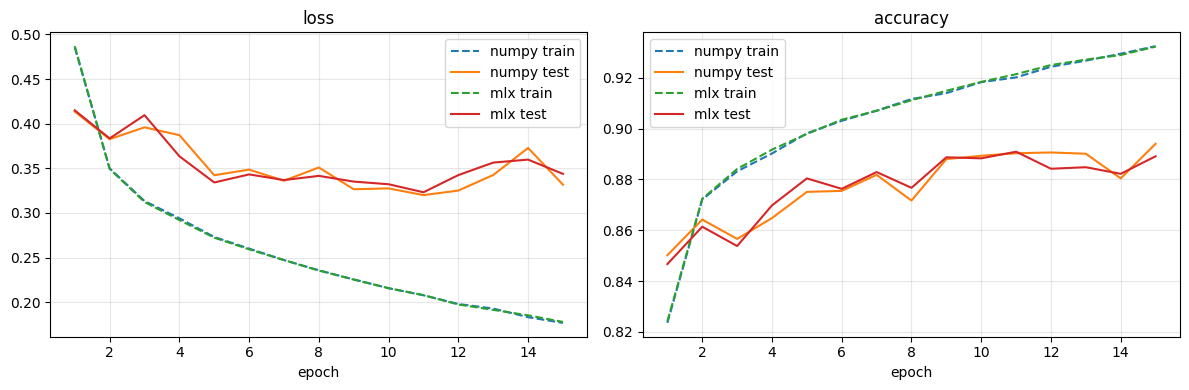

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_x = range(1, EPOCHS + 1)

for backend, res in results.items():
  h = res["history"]
  axes[0].plot(epochs_x, h["train_loss"], label=f"{backend} train", linestyle="--")
  axes[0].plot(epochs_x, h["test_loss"], label=f"{backend} test")
  axes[1].plot(epochs_x, h["train_acc"], label=f"{backend} train", linestyle="--")
  axes[1].plot(epochs_x, h["test_acc"], label=f"{backend} test")

axes[0].set_title("loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 클래스별 정확도

Fashion-MNIST 는 클래스 사이 시각적 유사성이 있어서, 어느 클래스가 잘 안 맞는지 보면 재밌다 (보통 셔츠 vs 풀오버 vs 코트가 헷갈림).

In [11]:
# 마지막 백엔드 (mlx) 모델로 클래스별 정확도
preds_all = []
for x, _ in iterate_minibatches(X_test_np, T_test_np, 256, shuffle=False):
  y = model.forward(x)
  preds_all.append(axon.current().to_numpy(xp.argmax(y, axis=1)))
preds = np.concatenate(preds_all)

print(f"{'class':<14} {'acc':>10} {'support':>10}")
for c in range(10):
  mask = T_test_np == c
  acc = (preds[mask] == c).sum() / mask.sum()
  print(f"{FASHION_CLASSES[c]:<14} {acc:>9.4%} {mask.sum():>10}")

class                 acc    support
T-shirt/top     87.7000%       1000
Trouser         97.2000%       1000
Pullover        81.4000%       1000
Dress           91.4000%       1000
Coat            77.4000%       1000
Sandal          94.5000%       1000
Shirt           69.8000%       1000
Sneaker         95.7000%       1000
Bag             96.0000%       1000
Ankle boot      98.0000%       1000
